# Name: Lucas Jones

# Assignment 05

Show your work. Include any code snippets that you used to generate answers. Complete this assignment individually. Unless otherwise stated, you can use code snippets to generate answers. If you are asked to do the calculations by hand, include your working.

## Question 1 [2 points]

Use the following code snippet to generate a data matrix $D$. Then create a scatter plot of the data, use $X1$ as the x-axis and $X2$ as the y-axis.

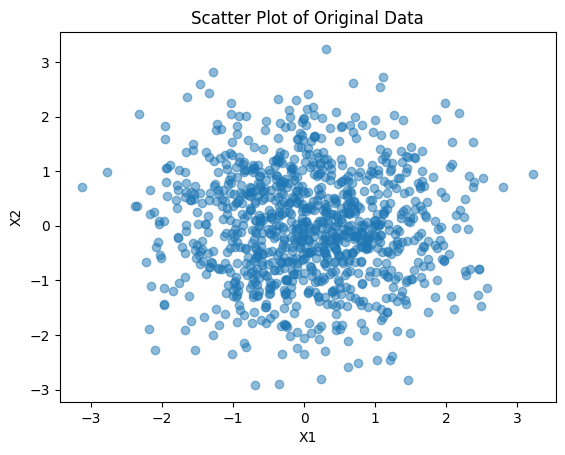

In [86]:
import numpy as np
import matplotlib.pyplot as plt

mu = np.array([0,0])
Sigma = np.array([[1,0], [0, 1]])
X1, X2 = np.random.multivariate_normal(mu, Sigma, 1000).T
D = np.array([X1, X2]).T

# scatter plot code
plt.scatter(D[:, 0], D[:, 1], alpha = 0.5)
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Scatter Plot of Original Data')
plt.show()

## Question 2 [8 points]

Using the scaling matrix $S$ and rotation matrix $R$, transform the data that you generated from Question 1, by multiplying each data instance of $x_{i}$ by $RS$. Let $RSD$ be the matrix of the transformed data. That is, each 2-dimensional row vector $x_{i}$ should be transformed into a 2-dimensional vector $RSx_{i}$ in $RSD$.

$$R = \begin{pmatrix} \cos(\theta) & -\sin\theta \\ \sin\theta & \cos(\theta) \end{pmatrix}, \quad \theta = \frac{\pi}{4}, \quad S = \begin{pmatrix} 3 & 0 \\ 0 & 4 \end{pmatrix}$$

In [87]:
theta = np.pi / 4

R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
S = np.array([[3, 0], [0, 4]])
RS = R @ S
RSD = (RS@D.T).T #transfom data
print(RSD)



[[ 2.40238993  1.55800494]
 [ 2.12886591  0.96263245]
 [ 1.93130029 -0.15185076]
 ...
 [-1.01219332  3.64691259]
 [-3.74770972  1.70237673]
 [ 0.67806625  1.96592362]]


### Question 2a [4 points]

Plot the transformed data in $RSD$ matrix in the same figure as the original data $D$, using different colors to differentiate between the original and transformed data.

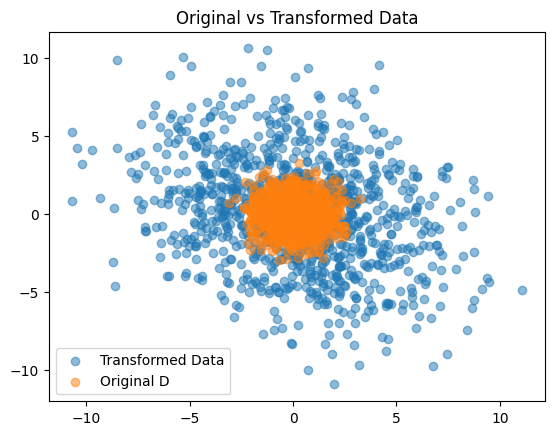

In [88]:
plt.scatter(RSD[:, 0], RSD[:, 1], alpha=0.5, label='Transformed Data')
plt.scatter(D[:, 0], D[:, 1], alpha=0.5, label='Original D')
plt.legend()
plt.title('Original vs Transformed Data')
plt.show()

### Question 2b [2 points]

What is the covariance matrix of the transformed data $RSD$?

In [89]:
cov_RSD =np.cov(RSD.T)
print(cov_RSD)

[[13.1749904  -3.69321936]
 [-3.69321936 12.52660493]]


### Question 2c [1 point]

What is the total variance of the transformed data $RSD$?

In [90]:
RSD_TotVar = np.trace(cov_RSD)
print(RSD_TotVar)

25.701595328657923


### Question 2d [1 point]

What is the total variance of the original data in $D$?

In [91]:
D_TotVar = np.trace(np.cov(D.T))
print(D_TotVar)

2.0515097646021117


## Question 3 [8 points]

Use sklearn's PCA function to transform the data matrix $RSD$ from Question 2 to a 2-dimensional space where the coordinate axes are the principal components.

In [92]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_RSD = pca.fit_transform(RSD)
print(pca_RSD)

[[ 0.66851595  2.61077287]
 [ 0.86899038  1.98699903]
 [ 1.47612534  1.03175448]
 ...
 [-3.26033545  1.84458709]
 [-3.96393556 -1.43706136]
 [-0.87849982  1.74680989]]


### Question 3a [4 points]

Plot the PCA-transformed data, with x-axis corresponding to the first principal component and y-axis corresponding to the second principal component.

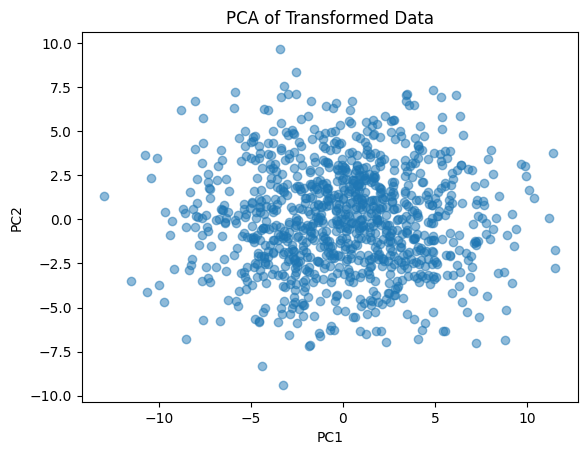

In [93]:
plt.scatter(pca_RSD[:, 0], pca_RSD[:, 1], alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of Transformed Data')
plt.show()

### Question 3b [2 points]

What is the covariance matrix of the PCA-transformed data? Do you see something interesting here or not? Explain why.

In [94]:
PCA_cov = np.cov(pca_RSD.T)
print(PCA_cov)  

[[1.65582186e+01 2.53206420e-15]
 [2.53206420e-15 9.14337671e+00]]


I Notice that the PCA removes correlation, the diagonal values are nearly zero.

### Question 3c [2 points]

What is the fraction of total variance captured in the direction of the first principal component? What is the fraction of the variance captured in the direction of the second principal component?

In [95]:
print("Fraction of variance captured by princinpal component 1 & 2", pca.explained_variance_ratio_)

Fraction of variance captured by princinpal component 1 & 2 [0.64424867 0.35575133]


## Question 4 [18 points]

Load the Boston dataset into Python (This should be in Canvas). Use sklearn's PCA function to perform dimensionality reduction.

In [96]:
import pandas as pd

df = pd.read_csv('Boston.csv')
Bos = np.array(df)
print(Bos)


[[0.0000e+00 6.3200e-03 1.8000e+01 ... 2.9600e+02 1.5300e+01 4.9800e+00]
 [1.0000e+00 2.7310e-02 0.0000e+00 ... 2.4200e+02 1.7800e+01 9.1400e+00]
 [2.0000e+00 2.7290e-02 0.0000e+00 ... 2.4200e+02 1.7800e+01 4.0300e+00]
 ...
 [5.0300e+02 6.0760e-02 0.0000e+00 ... 2.7300e+02 2.1000e+01 5.6400e+00]
 [5.0400e+02 1.0959e-01 0.0000e+00 ... 2.7300e+02 2.1000e+01 6.4800e+00]
 [5.0500e+02 4.7410e-02 0.0000e+00 ... 2.7300e+02 2.1000e+01 7.8800e+00]]


### Question 4a [5 points]

First standard-normalize the data. Then, create a scatter plot of the 2-dimensional PCA transformed normalized Boston data, with x-axis corresponding to the first principal component and y-axis corresponding to the second principal component.

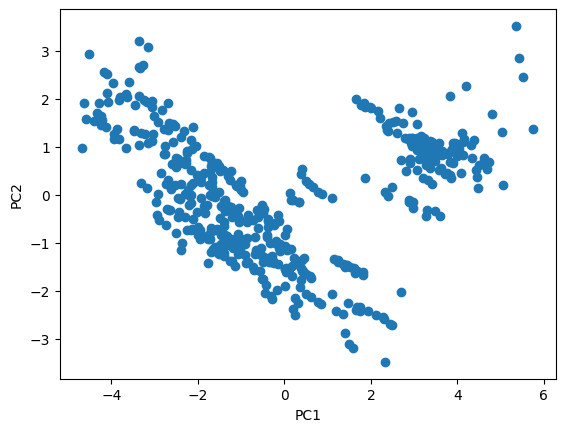

In [97]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
Bos_scaled = scaler.fit_transform(Bos)
Bos_pca = pca.fit_transform(Bos_scaled)

plt.scatter(Bos_pca[:, 0], Bos_pca[:, 1])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

### Question 4b [3 points]

Create a plot of the fraction of the variance explained by the first $r$ components. Include all possible dimensions in this plot. (13 dimensions)

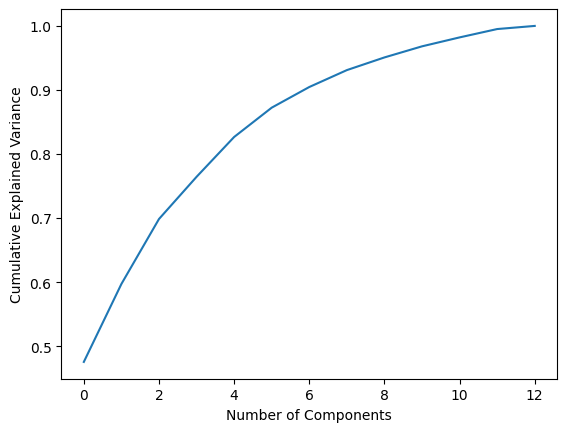

In [98]:
pca_full = PCA()
pca_full.fit_transform(Bos_scaled)

frac_var = np.cumsum(pca_full.explained_variance_ratio_)
plt.plot(frac_var)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.show()

### Question 4c [1 point]

If we want to capture at least 90% of the variance of the normalized Boston data, how many principal components should we use?

In [99]:
PCs = np.argmax(frac_var >= 0.9) +1
print("Components needed for 90% variance:", PCs)

Components needed for 90% variance: 7


### Question 4d [1 point]

If we use only the first two principal components, what is the fraction of the total variance captured by them?

In [100]:
var_frac = sum(pca.explained_variance_ratio_)
print("Variance explained by first 2 PCs:", var_frac)

Variance explained by first 2 PCs: 0.5971466471014016


### Question 4e [4 points]

Use scikit-learn's implementation of k-means to find 2 clusters in the two-dimensional, PCA-transformed normalized Boston dataset (the input to the k-means should be the data plotted in 4a). Plot the 2-dimensional data with colors corresponding to predicted cluster membership for each point. Moreover, plot the two centroids found by the k-means algorithm on the same plot.

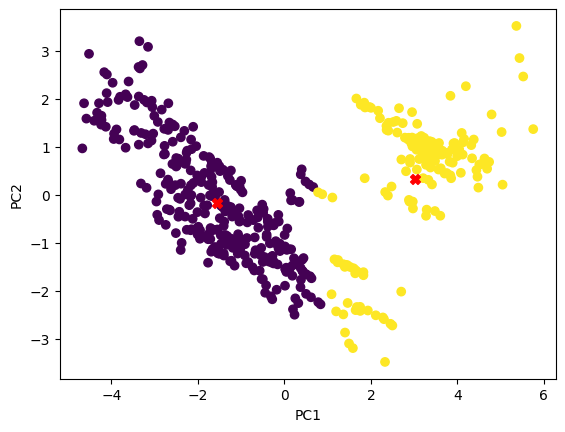

In [101]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=0)
km_label = kmeans.fit_predict(Bos_pca)
centers = kmeans.cluster_centers_

plt.scatter(Bos_pca[:, 0], Bos_pca[:, 1], c=km_label)
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=50)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

### Question 4f [4 points]

Use scikit-learn's implementation of **DBSCAN** to find clusters in the two-dimensional, PCA-transformed normalized Boston dataset (the input to the **DBSCAN** should be the data plotted in 4a). Plot the 2-dimensional data with colors corresponding to predicted cluster membership for each point. Noise points should be colored with a different color than the cluster colors.

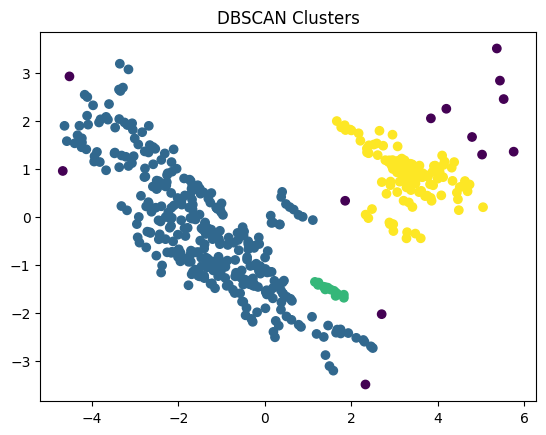

In [102]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.5, min_samples=5)
db_label = db.fit_predict(Bos_pca)

plt.scatter(Bos_pca[:, 0], Bos_pca[:, 1], c=db_label)
plt.title('DBSCAN Clusters')
plt.show()

## Question 5

Use the following code snippet to load the California housing dataset. (You can keep this dataset in any data structure you like — there is no need to keep it as a pandas frame.)

In [103]:
from sklearn.datasets import fetch_california_housing
california_housing = fetch_california_housing(as_frame=True)
df = california_housing.frame
print(california_housing.target)

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64


### Question 5a [2 points]

First, remove the target column from the dataset and then standard normalize the dataset.

In [104]:
i = df.drop(columns=['MedHouseVal'])
scaler = StandardScaler()
i_scaled = scaler.fit_transform(i)
print(i_scaled)


[[ 2.34476576  0.98214266  0.62855945 ... -0.04959654  1.05254828
  -1.32783522]
 [ 2.33223796 -0.60701891  0.32704136 ... -0.09251223  1.04318455
  -1.32284391]
 [ 1.7826994   1.85618152  1.15562047 ... -0.02584253  1.03850269
  -1.33282653]
 ...
 [-1.14259331 -0.92485123 -0.09031802 ... -0.0717345   1.77823747
  -0.8237132 ]
 [-1.05458292 -0.84539315 -0.04021111 ... -0.09122515  1.77823747
  -0.87362627]
 [-0.78012947 -1.00430931 -0.07044252 ... -0.04368215  1.75014627
  -0.83369581]]


### Question 5b [4 points]

Run the DBSCAN clustering algorithm on the standard normalized data (output of 5a). Plot the cluster information on a scatter plot where the x-axis is the Longitude and y-axis is the Latitude. Each point should contain a color corresponding to its cluster that you predicted using **DBSCAN**.

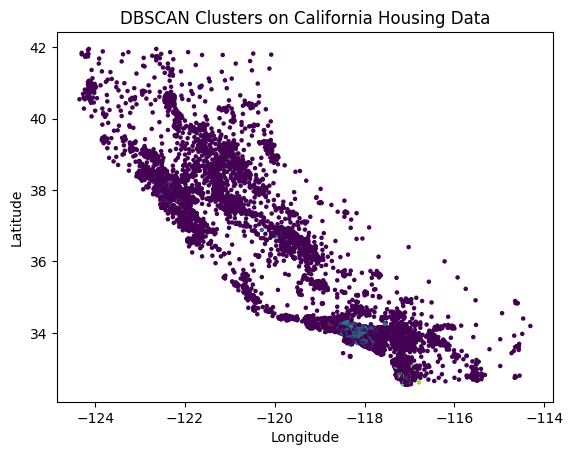

In [105]:
db = DBSCAN(eps=0.3, min_samples=10)
db_label = db.fit_predict(i_scaled)

lon = df['Longitude'].values
lat = df['Latitude'].values

plt.scatter(lon, lat, c=db_label, s=5)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('DBSCAN Clusters on California Housing Data')
plt.show()
